# Do small towns provide better education?

England's smaller towns post better educational outcomes than its larger ones.
That is not in dispute — it is in the data, and the [ONS analysis this dataset
comes from](https://www.ons.gov.uk/peoplepopulationandcommunity/educationandchildcare/articles/whydochildrenandyoungpeopleinsmallertownsdobetteracademicallythanthoseinlargertowns/2023-07-25)
is built around the question in its title.

The interesting question is *why*, and it has at least two answers with opposite
policy implications:

1. **Something about small towns helps.** Smaller schools, tighter communities,
   less anonymity. If so, the lesson is about scale.
2. **Small towns are simply less deprived**, and deprivation is what drives
   attainment. If so, town size is a bystander, and the lesson is about money.

These are indistinguishable in a correlation and easy to conflate in a
regression. Telling them apart requires committing to a causal structure first.

**What I find:** the second explanation, and more strongly than expected. Once
deprivation is held fixed, the small-town advantage does not merely vanish —
**it reverses.** Large towns come out ahead.

> This notebook estimates effects under an explicitly stated causal graph from
> observational data. The graph is an assumption, not a finding, and the
> [limitations](#Limitations) section is not boilerplate — one of the
> assumptions is doing real work and I flag where it could break.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from dowhy import CausalModel

from duplo import CausalDAG, effect_comparison, set_theme
from duplo.style import PALETTE

set_theme()
pd.set_option("display.precision", 3)

## The data

1,104 English towns, from the ONS's *Why do children and young people in smaller
towns do better academically than those in larger towns?* release (2011 Census
geography joined to attainment data). Published under the Open Government
Licence v3.0 — see [`data/README.md`](../data/README.md).

- `education_score` — a standardised composite of attainment and post-16
  destinations. Mean 0 across all towns; higher is better.
- `size_flag` — Small / Medium / Large town.
- `income_flag` — deprivation band, from local income data.
- `rgn11nm` — region (8 levels here).
- `coastal` — coastal or not.

I keep only the three ordinary town sizes, dropping cities and the London
built-up areas. Cities are a different kind of place, and with 18 of them there
is no power to say anything about them anyway.

In [2]:
df = pd.read_csv("../data/english_education.csv")

SIZES = ["Small Towns", "Medium Towns", "Large Towns"]
towns = (
    df[df["size_flag"].isin(SIZES)]
    [["coastal", "rgn11nm", "size_flag", "income_flag", "education_score"]]
    .dropna()
    .copy()
)
towns["size_flag"] = pd.Categorical(towns["size_flag"], categories=SIZES, ordered=True)
towns["size_numeric"] = towns["size_flag"].cat.codes  # 0, 1, 2

print(f"{len(towns)} towns, {len(df) - len(towns)} dropped (cities, London, missing)")
towns.groupby("size_flag", observed=True)["education_score"].agg(["count", "mean", "std"])

1082 towns, 22 dropped (cities, London, missing)


,count,mean,std
size_flag,,,
Small Towns,662,0.297,3.887
Medium Towns,331,-0.253,3.324
Large Towns,89,-0.811,2.298


There is the raw pattern: small towns average **+0.30**, large towns
**−0.81**. A gap of about 1.1 points, or roughly 0.3 standard deviations.

And here is the fact that should make you suspicious of reading that as an
effect of size:

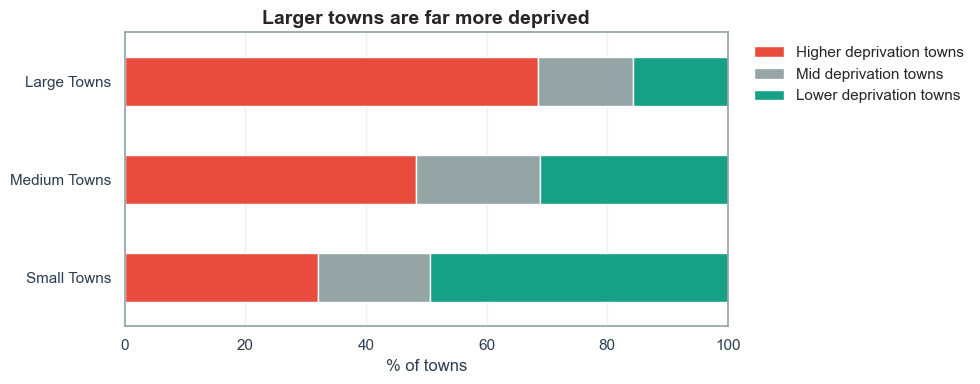

income_flag,Higher deprivation towns,Lower deprivation towns,Mid deprivation towns
size_flag,,,
Small Towns,32.0,49.4,18.6
Medium Towns,48.3,31.1,20.5
Large Towns,68.5,15.7,15.7


In [3]:
deprivation = pd.crosstab(
    towns["size_flag"], towns["income_flag"], normalize="index"
).loc[SIZES] * 100

ax = deprivation[["Higher deprivation towns", "Mid deprivation towns",
                  "Lower deprivation towns"]].plot(
    kind="barh", stacked=True, figsize=(10, 4),
    color=[PALETTE["coral"], PALETTE["grey"], PALETTE["teal"]], edgecolor="white",
)
ax.set_xlabel("% of towns")
ax.set_ylabel("")
ax.set_title("Larger towns are far more deprived", fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

deprivation.round(1)

**32%** of small towns are in the higher-deprivation band, against
**69%** of large towns. Town size and deprivation are deeply entangled in
England, which is what makes the naive comparison uninterpretable — it is
comparing places that differ in more than size.

---
## Stating the assumptions

Before estimating anything, the causal structure I am willing to defend:

- **Region → town size.** The north/south split in where large towns are.
- **Region → deprivation.** Regional economies differ.
- **Coastal → deprivation.** Coastal towns are systematically poorer.
- **Town size → deprivation.** Larger post-industrial towns carry more
  deprivation; this is the direction I am asserting, and it is arguable.
- **Deprivation → education score.** The mechanism of interest.
- **Town size → education score.** Any direct effect of size — school size,
  community, whatever "small town" means over and above income.

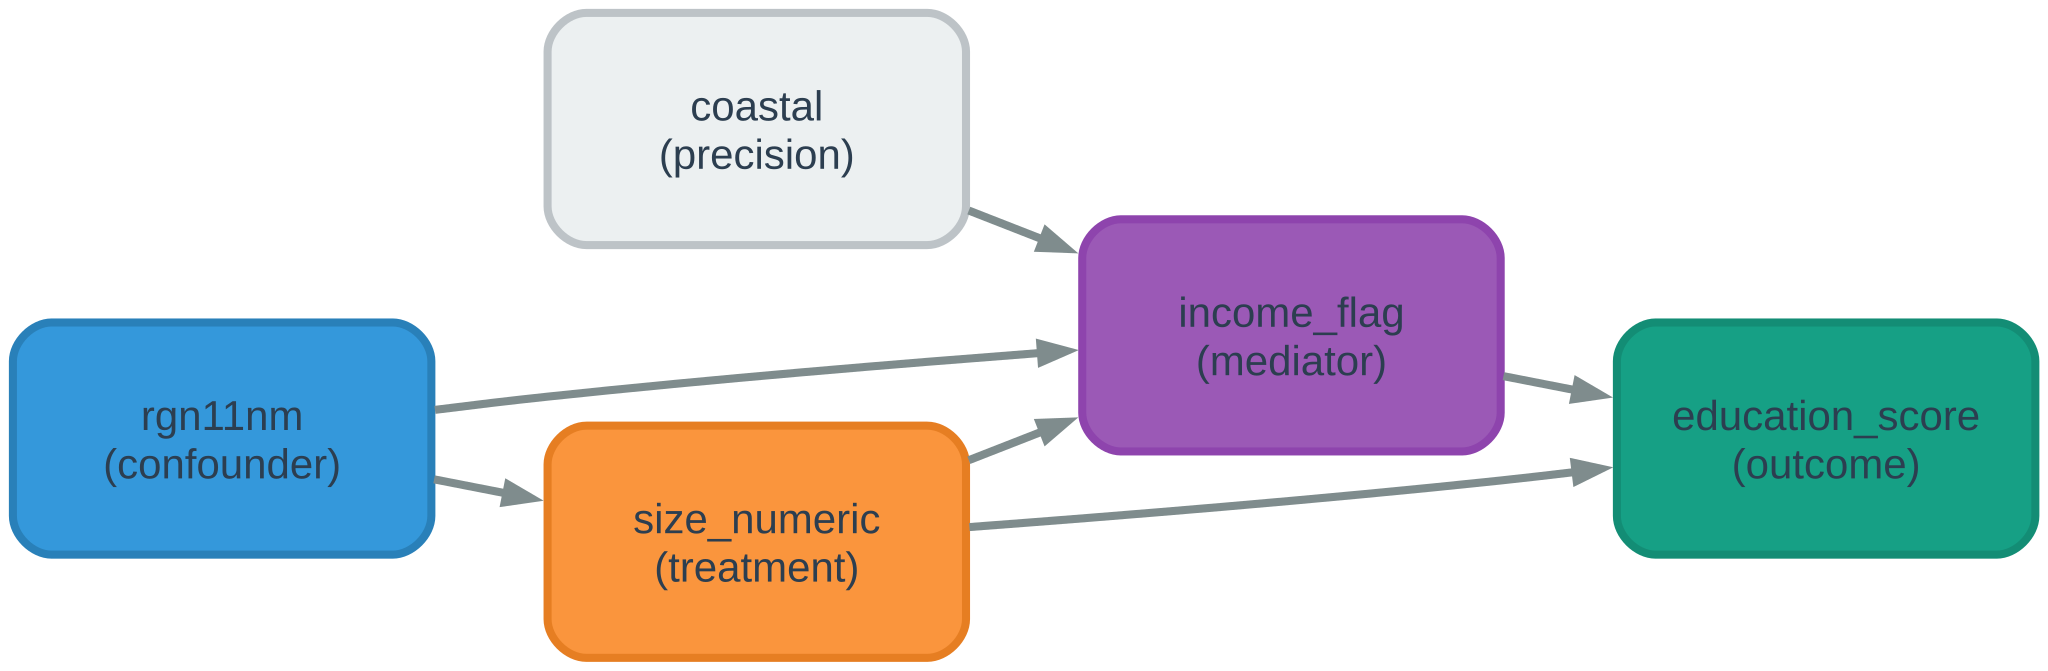

In [4]:
dag = (
    CausalDAG()
    .add("coastal",       to=["income_flag"])
    .add("rgn11nm",       to=["income_flag", "size_numeric"])
    .add("size_numeric",  to=["income_flag", "education_score"])
    .add("income_flag",   to=["education_score"])
    .add("education_score")
)
dag.draw("size_numeric", "education_score", save_path="figures/uk_education_dag.png")

**The colours are computed, not chosen.** When I first drew this
graph I hand-labelled `income_flag` as a confounder, because that is what
deprivation intuitively feels like — a background condition muddying the
comparison. But look at the arrows I actually drew: `size → income → education`.
That is a **mediator**. Deprivation is partly a *consequence* of town size in
this graph, not just a common cause.

The label and the arrows disagreed, and nothing caught it, because the label was
something I asserted rather than something the graph implied. Deriving the role
from the structure makes that class of error impossible:

In [5]:
print(dag.explain("size_numeric", "education_score"))

Treatment: size_numeric
Outcome:   education_score

MEDIATOR: income_flag
    adjusting for it gives the DIRECT effect, not the total effect
CONFOUNDER: rgn11nm
    adjust for it -- it is a common cause and leaves an open backdoor path
PRECISION: coastal
    optional -- affects only the outcome, so it tightens estimates without changing the estimand

WHAT A BACKDOOR ADJUSTMENT GIVES YOU:
    Adjusting for {rgn11nm} -> TOTAL effect (through every pathway).
    Adding the mediator(s) {income_flag} -> DIRECT effect only.
    These answer different questions. Say which one you report.


This distinction is not cosmetic — it determines which question
gets answered:

- Adjust for **region only** → the **total effect** of town size, including
  everything that flows through deprivation.
- Adjust for **region and deprivation** → the **direct effect**, town size
  holding deprivation fixed.

Both are legitimate. They are answers to different questions, and the entire
finding here is that they point in *opposite directions*.

---
## Step 1 — Identification

DoWhy's `identify_effect()` asks whether the effect is computable at all from
observed data under this graph, before any data is touched. It returns an
*estimand*: which variables to adjust for.

In [6]:
model = CausalModel(
    data=towns,
    treatment="size_numeric",
    outcome="education_score",
    graph=dag.to_dot(),
)
estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Backdoor set:", estimand.get_backdoor_variables())
print("Instruments :", estimand.get_instrumental_variables())

Backdoor set: ['rgn11nm']
Instruments : []


The backdoor set is `['rgn11nm']` — **region only**. Deprivation
is correctly excluded, because a valid backdoor set can never contain a
descendant of the treatment, and in this graph deprivation is one.

So DoWhy's default estimate here is the **total effect**. Worth stating
explicitly, because it is exactly the thing an unlabelled "causal effect
estimate" leaves ambiguous.

### A discrepancy worth chasing

Running DoWhy's linear regression and the equivalent `statsmodels` fit gives two
different numbers. Small, but a number I cannot explain is a number I should not
report:

In [7]:
est_default = model.estimate_effect(estimand, method_name="backdoor.linear_regression")
est_nomod   = model.estimate_effect(estimand, method_name="backdoor.linear_regression",
                                    effect_modifiers=[])
ols_total   = smf.ols("education_score ~ size_numeric + C(rgn11nm)", data=towns).fit()

print(f"DoWhy, defaults            : {est_default.value: .4f}")
print(f"DoWhy, effect_modifiers=[] : {est_nomod.value: .4f}")
print(f"statsmodels equivalent     : {ols_total.params['size_numeric']: .4f}")
print()
print("DoWhy auto-detected these effect modifiers:",
      est_default.estimator._effect_modifier_names)

DoWhy, defaults            : -0.6658
DoWhy, effect_modifiers=[] : -0.6976
statsmodels equivalent     : -0.6976

DoWhy auto-detected these effect modifiers: ['coastal']


DoWhy saw that `coastal` causes the outcome without causing the
treatment, classified it as an **effect modifier**, and silently added a
`size × coastal` interaction — so its default estimate is an *average* over a
heterogeneous effect, not a single slope. Suppress that and it matches
`statsmodels` exactly.

Neither is wrong; they estimate different things. But the interaction was never
requested, and nothing in the output announces it. Worth knowing about a library
whose selling point is making assumptions explicit.

Since it turned up, is the heterogeneity real?

In [8]:
interaction = smf.ols(
    "education_score ~ size_numeric * C(coastal) + C(rgn11nm)", data=towns
).fit()
term = "size_numeric:C(coastal)[T.Non-coastal]"
print(f"size x coastal interaction: {interaction.params[term]:+.3f}  (p = {interaction.pvalues[term]:.3f})")

size x coastal interaction: -0.815  (p = 0.082)


p = 0.08 — suggestive, not conclusive, on 153 coastal towns. I
note it and move on rather than building on it. For everything below I use the
explicit specification with no auto-detected interactions, so the estimand stays
the one I chose.

---
## Step 2 — The total effect

`size_numeric` codes Small/Medium/Large as 0/1/2, and treating that as
continuous assumes the Small→Medium step equals the Medium→Large step. That is
an assumption I have no reason to make, so I fit size as a **categorical**
variable and let the data decide.

In [9]:
def size_effects(formula_extra=""):
    """Effects of each size band vs Small Towns, adjusting for the given extras."""
    fit = smf.ols(
        'education_score ~ C(size_flag, Treatment("Small Towns")) + C(rgn11nm)'
        + formula_extra,
        data=towns,
    ).fit()
    rows = {}
    for term in fit.params.index:
        if "size_flag" not in term:
            continue
        band = term.split("T.")[1].rstrip("]")
        rows[band] = {"effect": fit.params[term], "se": fit.bse[term],
                      "p": fit.pvalues[term]}
    return pd.DataFrame(rows).T, fit

total, fit_total = size_effects()
print("TOTAL effect vs Small Towns (adjusting for region):")
total

TOTAL effect vs Small Towns (adjusting for region):


,effect,se,p
Medium Towns,-0.788,0.243,0.001
Large Towns,-1.283,0.402,0.001


Both bands are significantly worse than small towns, and the
gap widens with size: **−0.79** for medium, **−1.28** for large.

On the linearity question: if the effect were linear in the 0/1/2 coding, large
towns would sit at exactly twice medium (−1.58). They sit at −1.28, so the
relationship is monotonic but slightly sub-linear — the second step is smaller
than the first. The continuous coding is a decent approximation that mildly
overstates the large-town gap. I use the categorical version from here.

---
## Step 3 — The decomposition

Now the question the whole notebook exists for. The total effect above runs
through *every* pathway, including deprivation. Adding deprivation to the
adjustment set closes that pathway and leaves the direct effect.

In [10]:
direct, fit_direct = size_effects(" + C(income_flag)")
print("DIRECT effect vs Small Towns (adjusting for region AND deprivation):")
direct

DIRECT effect vs Small Towns (adjusting for region AND deprivation):


,effect,se,p
Medium Towns,0.317,0.184,0.086
Large Towns,0.702,0.307,0.022


In [11]:
decomposition = pd.DataFrame({
    "Total effect":    total["effect"],
    "Direct effect":   direct["effect"],
}).loc[["Medium Towns", "Large Towns"]]
decomposition["Indirect (via deprivation)"] = (
    decomposition["Total effect"] - decomposition["Direct effect"]
)
decomposition.round(3)

,Total effect,Direct effect,Indirect (via deprivation)
Medium Towns,-0.788,0.317,-1.105
Large Towns,-1.283,0.702,-1.985


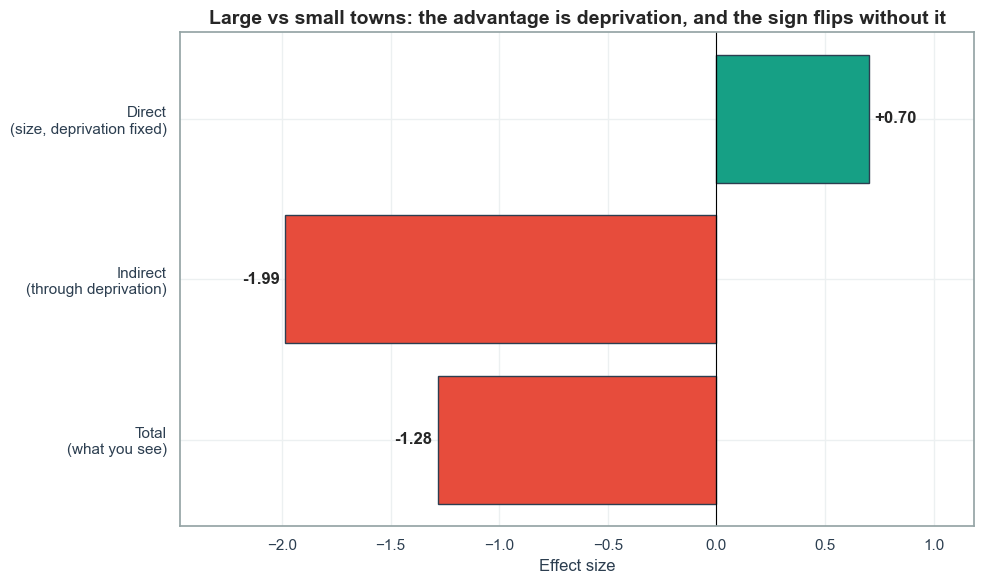

In [12]:
large = decomposition.loc["Large Towns"]
ax = effect_comparison(
    {
        "Total\n(what you see)":            large["Total effect"],
        "Indirect\n(through deprivation)":  large["Indirect (via deprivation)"],
        "Direct\n(size, deprivation fixed)": large["Direct effect"],
    },
    "Large vs small towns: the advantage is deprivation, and the sign flips without it",
)
plt.show()

**The sign flips.**

Large towns look **1.28 points worse** than small towns. Every bit of that, and
more, runs through deprivation: the indirect pathway is **−1.99**. Hold
deprivation fixed and large towns come out **+0.70 points better** (p = 0.02).

Medium towns tell the same story more weakly: total −0.79, direct **+0.32**
(p = 0.09), so the reversal there is suggestive rather than established.

The small-town advantage is not a small-town advantage. It is a *less-deprived*
advantage that small towns happen to enjoy. And once you account for it, the
residual association points the other way — consistent with larger towns having
some educational advantage of their own (more schools, more sixth forms, more
choice) that deprivation more than cancels out.

### The size of the thing that actually matters

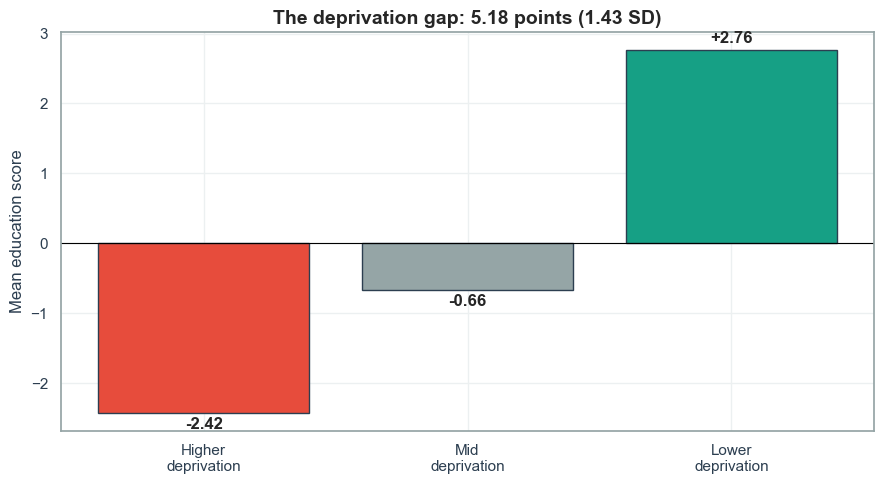

Deprivation gap : 5.18 points = 1.43 standard deviations
Largest size gap: 1.28 points = 0.35 standard deviations


In [13]:
by_income = (
    towns.groupby("income_flag")["education_score"].mean()
    .reindex(["Higher deprivation towns", "Mid deprivation towns",
              "Lower deprivation towns"])
)
gap = by_income["Lower deprivation towns"] - by_income["Higher deprivation towns"]
sd = towns["education_score"].std()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    ["Higher\ndeprivation", "Mid\ndeprivation", "Lower\ndeprivation"],
    by_income.values,
    color=[PALETTE["coral"], PALETTE["grey"], PALETTE["teal"]],
    edgecolor=PALETTE["dark_text"],
)
ax.bar_label(bars, fmt="%+.2f", fontweight="bold", padding=3)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean education score")
ax.set_title(f"The deprivation gap: {gap:.2f} points ({gap / sd:.2f} SD)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Deprivation gap : {gap:.2f} points = {gap / sd:.2f} standard deviations")
print(f"Largest size gap: {abs(total['effect']).max():.2f} points = "
      f"{abs(total['effect']).max() / sd:.2f} standard deviations")

**5.18 points, or 1.43 standard deviations**, between the least and
most deprived towns — against a largest town-size gap of 1.28 points (0.35 SD).
Deprivation is roughly **four times** the size of the thing the headline is
about.

Every number in the charts above is computed from the fitted models rather than
typed in, so they cannot drift out of sync with the analysis if the data or
specification changes.

---
## Step 4 — Trying to break it

Refutation tests do not confirm an estimate. They check it fails in the ways a
correct estimate should fail. Passing is weak evidence; failing is strong
evidence of a problem.

In [14]:
checks = {
    "random_common_cause":       "add an irrelevant confounder -> estimate should barely move",
    "placebo_treatment_refuter": "replace treatment with noise -> effect should collapse to ~0",
    "data_subset_refuter":       "re-estimate on random subsets -> estimate should be stable",
}

for method, expectation in checks.items():
    result = model.refute_estimate(estimand, est_nomod, method_name=method)
    print(f"{method}\n  {expectation}")
    print(f"  original {result.estimated_effect:+.4f} -> new {result.new_effect:+.4f}"
          f"   (p = {result.refutation_result['p_value']:.3f})"
          if result.refutation_result else
          f"  original {result.estimated_effect:+.4f} -> new {result.new_effect:+.4f}")
    print()

random_common_cause
  add an irrelevant confounder -> estimate should barely move
  original -0.6976 -> new -0.6971   (p = 0.900)

placebo_treatment_refuter
  replace treatment with noise -> effect should collapse to ~0
  original -0.6976 -> new +0.0152   (p = 0.960)

data_subset_refuter
  re-estimate on random subsets -> estimate should be stable
  original -0.6976 -> new -0.6941   (p = 0.920)



The placebo test is the informative one: replacing town size with
a random variable collapses the effect to approximately zero, so the estimate is
not an artefact of the adjustment machinery. Adding a random confounder and
re-fitting on subsets both leave it essentially unchanged.

None of this tests the assumption that matters, which is the graph itself. No
refutation test can.

---
## Limitations

**The direct effect rests on a stronger assumption than the total effect, and
this is the real weakness.** Estimating a direct effect by adjusting for a
mediator is only valid if nothing unmeasured causes *both* deprivation and
attainment. That is a lot to ask. School funding history, local labour markets,
selective schooling, decades of industrial decline — plausibly all of these
affect deprivation and attainment simultaneously, and none is in this dataset.
Any of them would bias the +0.70 direct effect. This is the standard difficulty
with mediation analysis: the total effect needs only that the treatment be
unconfounded, while the direct effect additionally needs the *mediator* to be
unconfounded. The reversal is the interesting finding and the least robust one.

**Towns are not pupils.** Every variable here is a town-level average, so
town-level relationships need not hold for individuals — the **ecological
fallacy**. This says nothing about whether a given child does better in a
smaller town.

**The size → deprivation arrow is a choice.** I assert that town size
influences deprivation. Reverse it and deprivation becomes a confounder rather
than a mediator, and the analysis changes shape. I find my direction more
plausible for post-industrial England, but it is an argument, not a measurement,
and the graph is what makes it visible enough to disagree with.

**Region is coarse.** Eight regions is a blunt control for geography. Within-region
variation in labour markets and school systems is left in the error term.

**Deprivation is three bands.** A crude proxy for a continuous quantity;
residual confounding within bands is likely, which if anything biases the direct
effect toward the total effect — meaning the true reversal could be larger.

**Cities are excluded**, so none of this extends to them.

---

## What it comes to

The headline is real: children in smaller English towns do better. The
explanation is not.

Small towns are less deprived, deprivation drives attainment, and town size is
mostly along for the ride. Hold deprivation fixed and the advantage does not
just disappear — it reverses, with large towns roughly 0.7 points ahead.

The difference between those two readings is a policy decision. "Small towns
produce better outcomes" points at something about scale and community. "Less
deprived places produce better outcomes, and small towns are less deprived"
points at money. The data are identical under both readings. Only the causal
structure separates them, and the structure has to be argued for — you cannot
recover it from the correlation matrix.

That is the case for teaching this. It is not an advanced topic to reach after
the regression material; it is the thing that determines whether the regression
answers the question you asked.

See [`00_concepts.ipynb`](00_concepts.ipynb) for the mechanics on simulated data
where the true answer is known.